# Notebook 1 - Data Preparation

## Diabetes 130-US Hospitals Dataset

## Introduction

This notebook prepares the raw dataset for analysis. It is a purely 
technical pipeline - no modelling, no causal reasoning, and no results 
appear here. Its sole purpose is to produce a clean, well-structured 
analytic dataset that all subsequent notebooks can load directly.

The raw source is the UCI Diabetes 130-US Hospitals dataset (Strack et 
al., 2014), covering 101,766 hospital encounters across 130 US hospitals 
between 1999 and 2008. The pipeline applies the following steps in order:

1. **Environment setup and data loading** - import libraries, load the 
   raw data, and inspect its structure and missingness
2. **Sample cleaning** - remove patients not at risk of readmission, 
   invalid records, and repeated encounters, leaving one observation 
   per patient
3. **Variable transformations** - convert age brackets to numeric 
   midpoints, create a female binary indicator, and construct a 
   weight observability proxy
4. **Outcome and treatment construction** - define the 30-day 
   readmission indicator, the primary binary insulin treatment, 
   alternative treatment definitions for sensitivity analysis, and 
   an exploratory four-level medication regime variable
5. **Diagnosis mapping** - group ICD-9 diagnosis codes into nine 
   broad clinical families following Strack et al. (2014)
6. **Laboratory and medication variables** - create binary indicators 
   for HbA1c and blood glucose test results, a medication change 
   indicator, and individual drug prescription dummies for all 22 
   non-insulin diabetes medications
7. **Categorical encoding** - group and one-hot encode race, payer 
   type, admission type, admission source, and medical specialty, 
   with explicit baseline categories chosen for interpretability
8. **Final dataset assembly and export** - collect all constructed 
   variables and save as `analysis_data.csv`
   
The output is a dataset of **67,315 unique patients** and **75 variables**.

> **Note on scope:** This notebook intentionally does not select which 
> variables to include as covariates in the causal model. That decision 
> is made after the causal DAG has been 
> drawn and the adjustment set has been formally justified. Essentially, this notebook 
> constructs all variables that *might* be relevant.

## 1. Environment Setup and Data Loading

### 1.1. Set up the environment.

In [83]:
# setup

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_folder_path = Path("..") # goes from project_final/code to project_final folder
data_folder_path = project_folder_path / "data"
figures_folder_path = project_folder_path / "figures"
tables_folder_path = project_folder_path / "tables"

data_path = data_folder_path / "diabetic_data.csv"

### 1.2. Load the raw data.

In [84]:
# load the raw CSV
df = pd.read_csv(data_path)
raw_df = df.copy() # we keep a copy of the raw data for reference

In [85]:
# print the head of the df 
raw_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [86]:
# get the number of unique values in each column
for col in raw_df.columns:
    uniques = raw_df[col].unique()
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {len(uniques)}")


Column: encounter_id
Number of unique values: 101766

Column: patient_nbr
Number of unique values: 71518

Column: race
Number of unique values: 6

Column: gender
Number of unique values: 3

Column: age
Number of unique values: 10

Column: weight
Number of unique values: 10

Column: admission_type_id
Number of unique values: 8

Column: discharge_disposition_id
Number of unique values: 26

Column: admission_source_id
Number of unique values: 17

Column: time_in_hospital
Number of unique values: 14

Column: payer_code
Number of unique values: 18

Column: medical_specialty
Number of unique values: 73

Column: num_lab_procedures
Number of unique values: 118

Column: num_procedures
Number of unique values: 7

Column: num_medications
Number of unique values: 75

Column: number_outpatient
Number of unique values: 39

Column: number_emergency
Number of unique values: 33

Column: number_inpatient
Number of unique values: 21

Column: diag_1
Number of unique values: 717

Column: diag_2
Number of 

### 1.3. Data inspection and additional checks

In [87]:
# check for number of rows and columns
print(f"Raw data shape: {raw_df.shape}")
print(f"Rows: {raw_df.shape[0]:,}")
print(f"Columns: {raw_df.shape[1]}")

Raw data shape: (101766, 50)
Rows: 101,766
Columns: 50


                   missing_count  missing_pct
weight                     98569         96.9
medical_specialty          49949         49.1
payer_code                 40256         39.6
race                        2273          2.2
diag_3                      1423          1.4
diag_2                       358          0.4
diag_1                        21          0.0


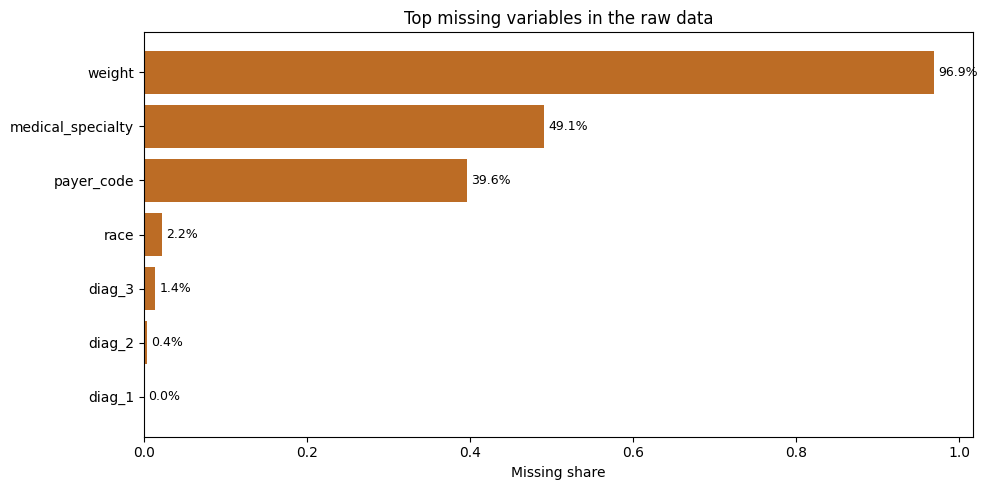

In [88]:
# check for which columns have missing values and how many
missing = (raw_df == "?").sum()
missing_pct = (missing / len(raw_df) * 100).round(1)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

print(missing_df)

fig, ax = plt.subplots(figsize=(10, 5))
top_missing = missing_df.head(12).iloc[::-1]
ax.barh(top_missing.index, top_missing["missing_pct"] / 100, color="#bc6c25")
ax.set_title("Top missing variables in the raw data")
ax.set_xlabel("Missing share")
for i, v in enumerate(top_missing["missing_pct"] / 100):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
fig.tight_layout()
plt.show()

We need to keep in mind as we go that we have three variables with a substantial number of missing values, namely `weight` (97%), `medical_specialty` (49%), and `payer_code` (40%).

In [89]:
# Check for the data types
raw_df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

## 2. Sample Cleaning

Following our research question ("What is the causal effect of in-hospital insulin prescription on 30-day readmission for diabetic patients, and does this effect vary across patient subgroups defined by age, gender, and prior hospitalisation history?"), we:
- remove "patients not meaniningfully at risk of readmission" $\rightarrow$ following the logic exposed in Strack et al. (2014)
- clean invalid gender records from the gender variable $\rightarrow$ 3 "unknown/invalid" rows
- keep only the first encounter per patient to have one independent observation per patient, which is required for the iid assumption underlying our estimator $\rightarrow$ following the logic exposed in Strack et al. (2014)

In [90]:
print(f"Number of rows before cleaning: {len(raw_df)}")

Number of rows before cleaning: 101766


### 2.1 Remove patients not meaningfully "at risk" for the readmission process.

The goal here is to focus on patients who can physically be readmitted to the hospital. This mean we do not deal with patients discharged to hospice or recorded as deceased since they cannot be readmitted within 30 days. This matters to us because it is the outcome variable we are aiming for. 

We also remove encounters with NULL, unmapped or invalid discharge disposition codes since they cannot be interpreted.

In [91]:
# those are the patients with hospice / deceased dispositions

# 11 expired -> deceased
# 13 hospice / home
# 14 hospice / medical facility
# 19 hospice / expired at home
# 20 hospice / expired in medical facility
# 21 hospice / expired, place unknown

# also removed:

# 18 NULL
# 25 not mapped
# 26 unknows / invalid
print(raw_df["discharge_disposition_id"].unique())

hospice_deceased_mapping = [11, 13, 14, 18,19, 20, 21, 25, 26]

raw_df = raw_df[~raw_df["discharge_disposition_id"].isin(hospice_deceased_mapping)]
print(f"Number of rows after hospice exclusion: {len(raw_df)}")

# BUT we consider all types of admissions


[25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Number of rows after hospice exclusion: 94663


### 2.2 Exclude "unknown/invalid" gender values.

In [92]:

# rationale: we want gender to be binary for the heterogeneity analysis
# "unknown/invalid" is a very small category of 3 rows (that would be hard to interpret in that context)
print(raw_df["gender"].unique())

raw_df = raw_df[raw_df["gender"] != "Unknown/Invalid"]
print(f"Number of rows after invalid/unknown gender exclusion: {len(raw_df)}")


<StringArray>
['Female', 'Male', 'Unknown/Invalid']
Length: 3, dtype: str
Number of rows after invalid/unknown gender exclusion: 94660


### 2.3 Keep the first encounter per patient.

Each patient may appear multiple times in the raw data across different 
hospital visits. We keep only the first encounter per patient, sorted 
by encounter_id. This gives one independent observation per patient, 
which is required for the iid assumption we will rely on for our estimation.

In [93]:

# so as to have a simple iid setup and not a very complicated interpretation of the estimands

# one could also choose to consider other encounter-selection rules, such as:
# - encounter with strongest diabetes relevance
# - latest encounter
# - a sort of patient-clustered repeated-event analysis

# 30% decrease in the number of rows
raw_df = raw_df.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first").reset_index(drop=True)
print(f"Number of rows after first encounter per patient selection: {len(raw_df)}")


Number of rows after first encounter per patient selection: 67315


## 3. Variable transformations

We create new variables and do some transformations on the existing ones: 
- clean age brackets $\rightarrow$ transform into a numeric value
- create a female dummy
- create a "weight is observed" dummy $\rightarrow$ since most of weight records is missing 96%

Change age to numeric midpoint values.


In [94]:
# that way age can enter linearly
# so no need to create many dummy variables
print(raw_df["age"].unique())
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95,
}

raw_df["age_numeric"] = raw_df["age"].map(age_mapping)


<StringArray>
[ '[80-90)', '[90-100)',  '[40-50)',  '[50-60)',  '[60-70)',  '[70-80)',
  '[20-30)',  '[10-20)',  '[30-40)',   '[0-10)']
Length: 10, dtype: str


Create a female dummy.

In [95]:
# create a female dummy 
raw_df["female"] = (raw_df["gender"] == "Female").astype(int)


Create a weight_observed dummy. 

In [96]:
# we can later use it as a potential "monitoring intensity heterogeneity" proxy
# it means the patient's weight was recorded at all (not its value)

# contrary to the intro paper who drops weight due to missing values,
# we use it to proxy "monitoring intensity heterogeneity"
# but it can also signify severity / ward protocols / documentation quality / etc.

# according to the paper:
# "prior to the HITECH legislation of the American Reinvestment and Recovery Act in 2009,
# hospitals and clinics were not required to capture weight in a structured format"

print(raw_df["weight"].unique())

raw_df["weight_observed"] = (raw_df["weight"] != "?").astype(int)

<StringArray>
[        '?',  '[75-100)',   '[50-75)',    '[0-25)', '[100-125)',   '[25-50)',
 '[125-150)', '[175-200)', '[150-175)',      '>200']
Length: 10, dtype: str


## 4. Outcome and Treatment variables construction

We create outcome and treatment variables $\rightarrow$ out main variables of interest:
- Y = early readmission $\rightarrow$ 1 if readmitted within 30 days, 0 otherwise
- D = any insulin exposure during the stay
- alternative D1 = steady insulin exposure during the stay
- alternative D2 = increased insulin exposure during the stay


Primary binary outcome construction : 30-day readmission.

In [97]:
print(raw_df["readmitted"].unique())

# ">30" and "NO" are both coded as zero in this project, because the estimand is EARLY readmission risk
raw_df["readmitted_30"] = (raw_df["readmitted"] == "<30").astype(int)

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str


Main binary treatment contruction : any insulin exposure during the stay. 

In [98]:
print(raw_df["insulin"].unique())

# any insulin exposure during the stay
raw_df["insulin_any"] = raw_df["insulin"].isin(["Steady", "Up", "Down"]).astype(int)

<StringArray>
['Steady', 'Down', 'No', 'Up']
Length: 4, dtype: str


Alternative binary treatment 1 : steady insulin exposure during the stay. 

In [99]:
# narrower treatment variant:
# useful as a sensitivity analysis -> stable treatment version
raw_df["insulin_steady_only"] = (raw_df["insulin"] == "Steady").astype(int)

Alternative binary treatment 2 : increasing insulin exposure during the stay. 

In [100]:
# escalating insulin only
raw_df["insulin_up_only"] = (raw_df["insulin"] == "Up").astype(int)

## 5. Clarifying diagnosis mapping

Following Strack et al. (2014), we map all ICD-9 codes into nine 
broad clinical families: circulatory, respiratory, digestive, 
diabetes, injury, musculoskeletal, genitourinary, neoplasms, and 
other. For each patient we then create nine binary indicators, one 
per family, equal to 1 if any of their three diagnosis codes falls 
into that family.

This serves two purposes in our analysis. First, it controls for the 
type of condition the patient was primarily admitted for, which is 
a potential confounder (for example, a patient admitted primarily for a 
circulatory condition is not necessarily the target of our analysis). Second, the `diag_diabetes` indicator 
specifically flags patients for whom diabetes is a primary or 
secondary diagnosis, which is relevant to the intensity of diabetes 
management during the stay.

We also add a `primary_diag_diabetes` to identify patients who were primarily admitted because of diabetes and distinguish them from those who have diabetes as a secondary condition.

In [101]:
# we map the icd9 diagnosis codes into broad diagnosis families
# they are more clinically interpretable and less sparse than raw codes -> reduced noise
# we follow the intro paper's grouping rules

diagnosis_groups = [
    "circulatory",
    "respiratory",
    "digestive",
    "diabetes",
    "injury",
    "musculoskeletal",
    "genitourinary",
    "neoplasms",
    "other",
]

def diag_group(code):
    """
    Based on the paper, Table 2:
      - circulatory: 390-459, 785
      - respiratory: 460-519, 786
      - digestive: 520-579, 787
      - diabetes: 250.xx
      - injury: 800-999
      - musculoskeletal: 710-739
      - genitourinary: 580-629, 788
      - neoplasms: 140-239
      - other: everything else
    """
    if pd.isna(code):
        return "other"

    code = str(code).strip().upper()

    if code in {"", "?", "NAN", "NONE", "NULL"}:
        return "other"

    # the paper puts E-V codes into "Other" as well
    if code.startswith("E") or code.startswith("V"):
        return "other"

    try:
        value = float(code)
    except ValueError:
        return "other"

    # diabetes first so 250.xx does not get absorbed by 240-279
    if 250 <= value < 251:
        return "diabetes"

    # main groups from the paper
    if 390 <= value < 460 or value == 785:
        return "circulatory"

    if 460 <= value < 520 or value == 786:
        return "respiratory"

    if 520 <= value < 580 or value == 787:
        return "digestive"

    if 580 <= value < 630 or value == 788:
        return "genitourinary"

    if 140 <= value < 240:
        return "neoplasms"

    if 800 <= value < 1000:
        return "injury"

    if 710 <= value < 740:
        return "musculoskeletal"

    # everything else in Table 2 is grouped into "Other"
    return "other"

In [102]:
# apply the function to diag_1, diag_2, diag_3 columns to create new columns with the diagnosis groups
for col in ["diag_1", "diag_2", "diag_3"]:
    raw_df[f"{col}_group"] = raw_df[col].apply(diag_group)

for group in diagnosis_groups:
    raw_df[f"diag_{group}"] = (
        (raw_df["diag_1_group"] == group)
        | (raw_df["diag_2_group"] == group)
        | (raw_df["diag_3_group"] == group)
    ).astype(int)

In [103]:
# checks
print(raw_df["diag_1_group"].unique())
print(raw_df["diag_2_group"].unique())
print(raw_df["diag_3_group"].unique())

<StringArray>
[    'circulatory',       'neoplasms',        'diabetes',     'respiratory',
           'other',          'injury', 'musculoskeletal',       'digestive',
   'genitourinary']
Length: 9, dtype: str
<StringArray>
[    'circulatory',       'neoplasms',           'other',        'diabetes',
          'injury',     'respiratory', 'musculoskeletal',   'genitourinary',
       'digestive']
Length: 9, dtype: str
<StringArray>
[          'other',     'respiratory',        'diabetes',          'injury',
       'neoplasms',     'circulatory',   'genitourinary', 'musculoskeletal',
       'digestive']
Length: 9, dtype: str


In [104]:
# We define a `primary_diag_diabetes` to identify patients who were primarily admitted because of diabetes and distinguish them from 
# those who have diabetes as a secondary condition.
raw_df["primary_diag_diabetes"] = (
    raw_df["diag_1"].apply(diag_group) == "diabetes"
).astype(int)

## 6. Constructing Binary Variables for Laboratory Results and Medication Variables

This section constructs binary indicators for three types of clinical 
information recorded during the hospital stay: laboratory test results 
(HbA1c and blood glucose), medication change, and 
individual non-insulin diabetes drug prescriptions. These variables could potentially serve us as **covariates** in the causal model because they capture dimensions 
of patient severity and treatment context that confound the 
relationship between insulin and readmission.

Essentially, we will create binary variables for the following:
- **HbA1c (A1Cresult):** Glycated haemoglobin, also written HbA1c or 
A1C, is a blood test measuring average blood sugar levels over the 
past 2–3 months.
- **Blood glucose (max_glu_serum):** Maximum serum glucose recorded 
during the stay.
- **Medicine change** during the hospital stay, either actual drug switching or simply dosage
- **Non-insulin medication dummies**

### 6.1 Lab tests:

Following Strack et al. (2014), we
create two binary indicators for each of the lab indicators:
- `A1C_tested` = 1 if the test was performed at all (Norm, >7, or >8)
- `A1C_abnormal` = 1 if the result was above the normal threshold 
  (>7 or >8)
  
and

- `glu_tested` = 1 if glucose was measured at all
- `glu_abnormal` = 1 if the result was above normal (>200 or >300)

In [105]:
# following the paper, for A1C and glucose we define normal and abnormal values
print(raw_df["A1Cresult"].unique())
print(raw_df["max_glu_serum"].unique())

raw_df["A1C_tested"] = raw_df["A1Cresult"].isin([">7", ">8", "Norm"]).astype(int)
raw_df["A1C_abnormal"] = raw_df["A1Cresult"].isin([">7", ">8"]).astype(int)

raw_df["glu_tested"] = raw_df["max_glu_serum"].isin([">200", ">300", "Norm"]).astype(int)
raw_df["glu_abnormal"] = raw_df["max_glu_serum"].isin([">200", ">300"]).astype(int)

print(raw_df["A1C_tested"].unique())
print(raw_df["glu_tested"].unique())


<StringArray>
[nan, '>7', '>8', 'Norm']
Length: 4, dtype: str
<StringArray>
[nan, '>300', 'Norm', '>200']
Length: 4, dtype: str
[0 1]
[0 1]


### 6.2 Medication change:

In [106]:
# a signal of active medication management during the stay
print(raw_df["change"].unique())
raw_df["med_change"] = (raw_df["change"] == "Ch").astype(int)

# following the paper, a “change of medication” means: 
# - any dosage change (increase or reduction)
# - change to a drug with a different generic name (type of drug/new drug)

# the data contains information about medications administered during the encounter
# any preadmission and discharge medications are not tracked

<StringArray>
['Ch', 'No']
Length: 2, dtype: str


### 6.3 Non-insulin medications (or their combinations):

In [107]:
non_insulin_meds = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

In [108]:
# any_non_insulin_meds indicator
raw_df["any_non_insulin_meds"] = (
    raw_df[non_insulin_meds]
    .isin(["Steady", "Up", "Down"])
    .any(axis=1)
    .astype(int)
)

Non-insulin meds (and their combinations as they may interact differently) binary vars:

In [109]:
# medication-specific binary indicators
for med in non_insulin_meds:
    raw_df[f"{med}_binary"] = raw_df[med].isin(["Steady", "Up", "Down"]).astype(int)

## 7. Four-level treatment variable - use in exploratory extensions

We noticed in the dataset the use of many different forms of medications. While insulin is the most common and is administered through injections, patients may also receive oral drugs (all the other non-insulin related diabetes medication in the dataset). 

We construct a four-level treatment variable that distinguishes 
between four medication regimes observed during 
the hospital stay:

| Value | Label | Definition |
|---|---|---|
| 0 | No diabetes medication | No diabetes drug prescribed during the stay |
| 1 | Oral medications only | At least one oral diabetes drug prescribed, no insulin |
| 2 | Insulin only | Insulin prescribed (injectable), no oral medications |
| 3 | Insulin + oral | Insulin prescribed alongside at least one oral medication |

The goal is to allow us after the main analysis is done to compare different regimes of treatment, which may combine different prescriptions, or simply have a cleaner comparison of the effectiveness of each course of treatment. 

In [110]:

# 0 = no diabetes meds
# 1 = oral meds only
# 2 = only insulin
# 3 = insulin + oral


raw_df["treatment_multivalued"] = np.select(
    [
        raw_df["diabetesMed"] == "No", # no diabetes meds
        (raw_df["insulin_any"] == 0) & (raw_df["any_non_insulin_meds"] == 1),  # oral only
        (raw_df["insulin_any"] == 1) & (raw_df["any_non_insulin_meds"] == 0),  # insulin only
        (raw_df["insulin_any"] == 1) & (raw_df["any_non_insulin_meds"] == 1),  # insulin + oral
    ],
    [0, 1, 2, 3]
)

## 8. Encoding Categorical Variables

We create dummies for variables with many categories:
- medical specialty (admitted to) e.g. GP
- payer type $\rightarrow$ in the US a hospital visit needs to be paid for (e.g. insurance, self-pay, Medicare)
- race
- admission source e.g. physician referral, emergency room, transfer from a hospital 
- admission type e.g. emergency, urgent, newborn

We also drop the following dummy categories (used as a baseline): 
- race: Caucasian $\rightarrow$ largest race group 
- payer_type: MC $\rightarrow$ meaningful as it is Medicare: a federal system of health insurance for people over 65 or with disabilities
- medical specialty: InternalMedicine $\rightarrow$ a strong clinical baseline for diabetes admissions, comprehensive care of adult patients.
- admission source: Emergency $\rightarrow$ most common and a natural benchmark for hospital admissions.
- admission type: Emergency $\rightarrow$ most common and a natural benchmark for hospital admissions.


In [111]:
print(raw_df["race"].unique()) # need to change "?" to "Unknown"
print(raw_df["payer_code"].unique()) # need to change "?" to "Unknown"
print(raw_df["medical_specialty"].unique()) # need to change "?" to "Unknown"

# admission type and admission source are mapped in a csv file attached to the dataset

<StringArray>
['Caucasian', 'AfricanAmerican', '?', 'Other', 'Hispanic', 'Asian']
Length: 6, dtype: str
<StringArray>
[ '?', 'MC', 'MD', 'HM', 'UN', 'BC', 'SP', 'CP', 'SI', 'DM', 'CM', 'CH', 'PO',
 'WC', 'OT', 'OG', 'MP', 'FR']
Length: 18, dtype: str
<StringArray>
[                                   '?',
                     'InternalMedicine',
               'Family/GeneralPractice',
                           'Cardiology',
                      'Surgery-General',
                          'Orthopedics',
                     'Gastroenterology',
                           'Nephrology',
                           'Psychiatry',
           'Orthopedics-Reconstructive',
                          'Pulmonology',
                        'Surgery-Neuro',
 'Obsterics&Gynecology-GynecologicOnco',
              'Pediatrics-CriticalCare',
                        'Endocrinology',
                              'Urology',
                            'Radiology',
             'Pediatrics-Endocrinology

### 8.1 Race

In [112]:
# keep all categories, replace ? with Unknown
raw_df["race_grouped"] = (
    raw_df["race"]
    .astype(str)
    .str.strip()
    .replace("?", "Unknown")
)

### 8.2 Payer type - records how the hospital visit is financed. 

In [113]:

# keep top 4 most frequent categories, collapse rest to Other
# HM is a type of private insurance plan (restricted provider networks and referrals required)
# BC is another private insurance provider, popular in the US
payer_cleaned = (
    raw_df["payer_code"]
    .astype(str)
    .str.strip()
    .replace("?", "Unknown")
)

top_payers = payer_cleaned.value_counts().index[:4]

raw_df["payer_code_grouped"] = np.where(
    payer_cleaned.isin(top_payers),
    payer_cleaned,
    "Other"
)


### 8.3 Admission type

In [114]:

# manual clinically meaningful grouping
admission_type_map = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Other", # Newborn, but we add to Other due to a small number of rows
    5: "Other", # Not Available
    6: "Other", # NULL
    7: "Other", # Trauma, but we add to Other due to a small number of rows
    8: "Other", # Not Mapped
}

raw_df["admission_type_id_grouped"] = (
    pd.to_numeric(raw_df["admission_type_id"], errors="coerce")
    .map(admission_type_map)
    .fillna("Other")
)

### 8.4 Admission source

In [115]:
# group by clinical meaning, using a csv attached to the main dataset
def map_admission_source(x):
    try:
        x = int(float(x))
    except (TypeError, ValueError):
        return "Other"

    if x == 7:
        return "Emergency"
    elif x in [1, 2, 3]:
        return "Referral"
    elif x in [4, 5, 6, 10, 22, 25]:
        return "Transfer"
    elif x in [18, 19]:
        return "HomeHealth"
    else:
        return "Other"

raw_df["admission_source_id_grouped"] = raw_df["admission_source_id"].apply(map_admission_source)


### 8.5 Medical specialty

In [116]:

# keep top 6 most frequent categories, collapse rest to Other
specialty_cleaned = (
    raw_df["medical_specialty"]
    .astype(str)
    .str.strip()
    .replace("?", "Unknown")
)

top_specialties = specialty_cleaned.value_counts().index[:6]

raw_df["medical_specialty_grouped"] = np.where(
    specialty_cleaned.isin(top_specialties),
    specialty_cleaned,
    "Other"
)


### 8.6 Final checks

Inspecting grouped results:

In [117]:

print(raw_df["race_grouped"].value_counts(dropna=False), "\n")
print(raw_df["admission_type_id_grouped"].value_counts(dropna=False), "\n")
print(raw_df["admission_source_id_grouped"].value_counts(dropna=False), "\n")
print(raw_df["payer_code_grouped"].value_counts(dropna=False), "\n")
print(raw_df["medical_specialty_grouped"].value_counts(dropna=False), "\n")

# payer type and medical specialty have the biggest groups marked as unknown -> potential issue


race_grouped
Caucasian          50309
AfricanAmerican    12094
Unknown             1885
Hispanic            1446
Other               1103
Asian                478
Name: count, dtype: int64 

admission_type_id_grouped
Emergency    34512
Elective     13139
Urgent       12479
Other         7185
Name: count, dtype: int64 

admission_source_id_grouped
Emergency    36105
Referral     21883
Other         4895
Transfer      4432
Name: count, dtype: int64 

payer_code_grouped
Unknown    27712
MC         19829
Other      12386
HM          3989
BC          3399
Name: count, dtype: int64 

medical_specialty_grouped
Unknown                   31896
InternalMedicine          10541
Other                      9468
Family/GeneralPractice     4721
Emergency/Trauma           4393
Cardiology                 4134
Surgery-General            2162
Name: count, dtype: int64 



One-hot encode our grouped categorical varables:

In [118]:
# we drop dummies here !!!

# we set category order so the first category dropped is our baseline

raw_df["race_grouped"] = pd.Categorical(
    raw_df["race_grouped"],
    categories=["Caucasian", "AfricanAmerican", "Hispanic", "Asian", "Other", "Unknown"],
    ordered=False,
)

raw_df["admission_type_id_grouped"] = pd.Categorical(
    raw_df["admission_type_id_grouped"],
    categories=["Emergency", "Urgent", "Elective", "Other"],
    ordered=False,
)

raw_df["admission_source_id_grouped"] = pd.Categorical(
    raw_df["admission_source_id_grouped"],
    categories=["Emergency", "Referral", "Transfer", "Other"],
    ordered=False,
)

raw_df["payer_code_grouped"] = pd.Categorical(
    raw_df["payer_code_grouped"],
    categories=["MC", "HM", "BC", "Other", "Unknown"], 
    ordered=False,
)

raw_df["medical_specialty_grouped"] = pd.Categorical(
    raw_df["medical_specialty_grouped"],
    categories=[
        "InternalMedicine",
        "Family/GeneralPractice",
        "Emergency/Trauma",
        "Cardiology",
        "Surgery-General",
        "Other",
        "Unknown"
    ],
    ordered=False,
)

# create dummies with chosen baselines dropped -> use 0/1

dummy_columns = pd.get_dummies(
    raw_df[
        [
            "race_grouped",
            "admission_type_id_grouped",
            "admission_source_id_grouped",
            "payer_code_grouped",
            "medical_specialty_grouped",
        ]
    ],
    prefix=["race", "admission_type", "admission_source", "payer", "specialty"],
    drop_first=True,
).astype(int)

# add dummy columns back to dataset
raw_df = pd.concat([raw_df, dummy_columns], axis=1)

print(dummy_columns.columns.tolist())


['race_AfricanAmerican', 'race_Hispanic', 'race_Asian', 'race_Other', 'race_Unknown', 'admission_type_Urgent', 'admission_type_Elective', 'admission_type_Other', 'admission_source_Referral', 'admission_source_Transfer', 'admission_source_Other', 'payer_HM', 'payer_BC', 'payer_Other', 'payer_Unknown', 'specialty_Family/GeneralPractice', 'specialty_Emergency/Trauma', 'specialty_Cardiology', 'specialty_Surgery-General', 'specialty_Other', 'specialty_Unknown']


# Final dataset = base columns + medications + dummies

We now assemble the final analytic dataset by selecting all 
constructed variables into one clean dataframe. 

The final dataset has three types of columns:

- **Covariates (X)** - variables used to control for confounding 
  in the causal model. These include demographics, lab results, 
  medication indicators, diagnosis categories, utilisation history, 
  and categorical dummies for race, payer, admission type, admission 
  source, and medical specialty.
- **Outcome (Y)** - `readmitted_30`, the 30-day readmission binary 
  indicator
- **Treatment variables (D)** - `insulin_any` (primary), 
  `insulin_steady_only`, `insulin_up_only` (sensitivity analysis), 
  and `treatment_multivalued` (exploratory extension)

In [119]:

base_columns = [

    # created in data prep section, we don't care abut the discharge disposition anymore
    "female",
    "age_numeric",  
    "weight_observed",
    "A1C_tested",
    "A1C_abnormal",
    "glu_tested",
    "glu_abnormal",
    "med_change",
    "any_non_insulin_meds",
    "primary_diag_diabetes",

    # this was already in the dataset, we keep it untouched 
    "time_in_hospital", # integer number of days between admission and discharge
    "num_lab_procedures", # number of lab tests performed during the encounter
    "num_procedures", # number of procedures (other than lab tests) performed during the encounter
    "num_medications", # number of distinct generic names administered during the encounter
    "number_outpatient", # number of outpatient visits of the patient in the year preceding the encounter
    "number_emergency", # number of emergency visits of the patient in the year preceding the encounter
    "number_inpatient", # number of inpatient visits of the patient in the year preceding the encounter
    "number_diagnoses", # number of diagnoses entered to the system (can be more then 3 even though we have diag_1, diag_2, diag_3)
]

# adding dummies for the non-insulin diabetes medications
base_columns = base_columns + [f"{med}_binary" for med in non_insulin_meds]

# adding different diagnosis dummies 
base_columns = base_columns + [f"diag_{group}" for group in diagnosis_groups]

# adding dummies for race, admission type, admission source, medical specialty, payer code
final_columns_x = base_columns + list(dummy_columns.columns)

# columns of interest 
final_columns_y = ["readmitted_30"]
final_columns_d = ["insulin_any", "insulin_steady_only", "insulin_up_only", "treatment_multivalued"]


In [120]:

# all columns for the final dataset
analysis_columns = final_columns_x + final_columns_y + final_columns_d

# analysis df
analysis_df = raw_df[analysis_columns].copy()

In [121]:
analysis_df.head()

,female,age_numeric,weight_observed,A1C_tested,A1C_abnormal,glu_tested,glu_abnormal,med_change,any_non_insulin_meds,primary_diag_diabetes,...,specialty_Emergency/Trauma,specialty_Cardiology,specialty_Surgery-General,specialty_Other,specialty_Unknown,readmitted_30,insulin_any,insulin_steady_only,insulin_up_only,treatment_multivalued
0,1,85,0,0,0,0,0,1,1,0,...,0,0,0,0,1,0,1,1,0,3
1,1,95,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,1,1,0,3
2,0,45,0,0,0,0,0,1,1,0,...,0,0,0,0,1,0,1,1,0,3
3,1,45,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,1,1,0,2
4,0,55,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,1,0,2


In [122]:
analysis_df.to_csv(data_folder_path / "analysis_data.csv", index=False)

In [123]:
print(f"Final data shape: {analysis_df.shape}")

Final data shape: (67315, 75)
